## Import libraries

In [45]:
#!pip install imblearn

In [46]:
import pandas as pd
import numpy as np

import glob
import os

import requests

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import zipfile

import xarray as xr

import folium
from folium.plugins import MarkerCluster

import pandas as pd
from geopy.geocoders import Nominatim

import geopandas as gpd
import cartopy.crs as ccrs

import imageio

from sklearn.neighbors import KDTree
from sklearn.neighbors import BallTree

from sklearn.preprocessing import RobustScaler

## Set parameters

In [47]:
decree_filename_base = 'arrete_'
decrees_folder_name = './../../data/raw/decrees'
communes_folder_name = './../../data/raw/opendatasoft'
weather_folder_name = './../../data/raw/weather/era5'
weather_ncfiles_folder_name = './../../data/raw/weather/era5/ncfiles2'
processed_data_folder_name = './../../data/processed'
output_data_folder_name = './../../data/processed/output'
decrees_filename = 'decrees.parquet'
decrees_locations_filename = 'decrees_locations.parquet'
communes_csv_filename = 'correspondance-code-insee-code-postal-202410.csv'
weather_filename = 'weather2.parquet'
weather_shema_filename = 'weather_shema2.csv'
weather_yearly_filename = 'weather2_yearly.parquet'
weather_yearly_shema_filename = 'weather_shema2_yearly.csv'
drought_filename = 'drought.parquet'
drought_shema_filename = 'drought_shema.csv'
drought_yearly_filename = 'drought_yearly.parquet'
drought_yearly_shema_filename = 'drought_yearly_shema.csv'
drought_commune_clean_filename = 'drought_commune_clean.parquet'
drought_commune_clean_shema_filename = 'drought_commune_clean_shema.csv'
drought_weather_filename = 'drought_weather.parquet'
drought_weather_shema_filename = 'drought_weather_shema.csv'
#weather_zip_file = "193fcd51a8958175843ecbbcaba057c8.zip"

## Load data

| Column    | Description                                      |
|-----------|--------------------------------------------------|
| date      | The date of the observation.                     |
| latitude  | The latitude coordinate of the observation point.|
| longitude | The longitude coordinate of the observation point.|
| number    | A unique identifier for the observation.         |
| expver    | Experiment version number.                       |
| u10       | 10-meter U-component of wind (eastward wind).    |
| v10       | 10-meter V-component of wind (northward wind).   |
| t2m       | 2-meter temperature (air temperature at 2 meters above the surface).|
| sp        | Surface pressure.                                |
| tp        | Total precipitation.                             |
| e         | Evaporation.                                     |
| sro       | Surface runoff.                                  |
| tcrw      | Total column water vapor.                        |
| stl1      | Soil temperature level 1.                        |
| stl2      | Soil temperature level 2.                        |
| slt       | Soil type.                                       |
| swvl1     | Volumetric soil water layer 1.                   |
| swvl2     | Volumetric soil water layer 2.                   |
| cvh       | High vegetation cover.                           |
| cvl       | Low vegetation cover.                            |
| tvh       | High vegetation type.                            |
| tvl       | Low vegetation type.                             |


## Import Data

In [48]:
# read the dataframe from parquet
import pandas as pd

df = pd.read_parquet(os.path.join(processed_data_folder_name, drought_weather_filename))




In [49]:
os.path.join(processed_data_folder_name, drought_weather_shema_filename)

'./../../data/processed/drought_weather_shema.csv'

In [50]:
# Load the schema (data types) from the file
schema = pd.read_csv(os.path.join(processed_data_folder_name, drought_weather_shema_filename), index_col=0).squeeze("columns")

In [51]:
# Apply the schema to the loaded dataframe
df = df.astype(schema.to_dict())

In [52]:
# Remove rows where applied_1 is equal to 0
df = df[df['applied_1'] != 0]

df_applied_ori = df.copy()

print(df)


      insee_1           nom_commune_1  latitude_1  longitude_1  year_1  \
9       10010            ARREMBECOURT   48.543296     4.606490    2000   
10      10011             ARRENTIERES   48.267992     4.739104    2000   
16      10018                   AUXON   48.092318     3.923462    2000   
23      10024                 AVREUIL   48.053139     3.998028    2000   
25      10026         BAILLY-LE-FRANC   48.522491     4.659134    2000   
...       ...                     ...         ...          ...     ...   
35990   95592             SERAINCOURT   49.042140     1.878670    2023   
35992   95598  SOISY-SOUS-MONTMORENCY   48.988408     2.300500    2023   
35994   95607                 TAVERNY   49.026732     2.221161    2023   
36002   95637                 VAUREAL   49.029507     2.024466    2023   
36011   95678           VILLIERS-ADAM   49.070289     2.239509    2023   

       year_count_1  year_duration_1  applied_1  decision_1 Code Postal_1  \
9               1.0              1

In [53]:
df.head()

,insee_1,nom_commune_1,latitude_1,longitude_1,year_1,year_count_1,year_duration_1,applied_1,decision_1,Code Postal_1,...,stl2_mean_2,slt_sum_2,slt_mean_2,swvl1_sum_2,swvl1_mean_2,swvl2_sum_2,swvl2_mean_2,latitude_rad_2,longitude_rad_2,distance_km
9,10010,ARREMBECOURT,48.543296,4.606490,2000,1.0,1.0,1,0,10330,...,11.691945,24.0,2.0,4.240410,0.353368,4.173016,0.347751,0.846485,0.078540,9.202538
10,10011,ARRENTIERES,48.267992,4.739104,2000,1.0,1.0,1,0,10200,...,11.360728,36.0,3.0,4.290780,0.357565,4.225537,0.352128,0.842121,0.082903,2.157139
16,10018,AUXON,48.092318,3.923462,2000,1.0,1.0,1,0,10130,...,11.610565,36.0,3.0,4.263848,0.355321,4.201031,0.350086,0.837758,0.069813,11.736634
23,10024,AVREUIL,48.053139,3.998028,2000,1.0,1.0,1,0,10130,...,11.610565,36.0,3.0,4.263848,0.355321,4.201031,0.350086,0.837758,0.069813,5.910659
25,10026,BAILLY-LE-FRANC,48.522491,4.659134,2000,1.0,1.0,1,0,10330,...,11.490936,24.0,2.0,4.288506,0.357376,4.234311,0.352859,0.846485,0.082903,7.145499


In [54]:
df.columns

Index(['insee_1', 'nom_commune_1', 'latitude_1', 'longitude_1', 'year_1',
       'year_count_1', 'year_duration_1', 'applied_1', 'decision_1',
       'Code Postal_1', 'Département_1', 'Région_1', 'Code Département_1',
       'Code Région_1', 'latitude_rad_1', 'longitude_rad_1', 'latitude_2',
       'longitude_2', 'year_2', 't2m_z_sum_2', 't2m_z_mean_2', 'tp_z_sum_2',
       'tp_z_mean_2', 'e_z_sum_2', 'e_z_mean_2', 'pev_z_sum_2', 'pev_z_mean_2',
       'stl1_z_sum_2', 'stl1_z_mean_2', 'stl2_z_sum_2', 'stl2_z_mean_2',
       'slt_z_sum_2', 'slt_z_mean_2', 'swvl1_z_sum_2', 'swvl1_z_mean_2',
       'swvl2_z_sum_2', 'swvl2_z_mean_2', 't2m_sum_2', 't2m_mean_2',
       'tp_sum_2', 'tp_mean_2', 'e_sum_2', 'e_mean_2', 'pev_sum_2',
       'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2', 'stl2_sum_2', 'stl2_mean_2',
       'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2', 'swvl1_mean_2', 'swvl2_sum_2',
       'swvl2_mean_2', 'latitude_rad_2', 'longitude_rad_2', 'distance_km'],
      dtype='object')

In [55]:
df.dtypes

insee_1                object
nom_commune_1          object
latitude_1            float64
longitude_1           float64
year_1                  int64
year_count_1          float64
year_duration_1       float64
applied_1               int64
decision_1              int64
Code Postal_1          object
Département_1          object
Région_1               object
Code Département_1     object
Code Région_1           int64
latitude_rad_1        float64
longitude_rad_1       float64
latitude_2            float64
longitude_2           float64
year_2                  int32
t2m_z_sum_2           float64
t2m_z_mean_2          float64
tp_z_sum_2            float64
tp_z_mean_2           float64
e_z_sum_2             float64
e_z_mean_2            float64
pev_z_sum_2           float64
pev_z_mean_2          float64
stl1_z_sum_2          float64
stl1_z_mean_2         float64
stl2_z_sum_2          float64
stl2_z_mean_2         float64
slt_z_sum_2           float64
slt_z_mean_2          float64
swvl1_z_su

In [56]:
df.select_dtypes(include=['object']).describe()

,insee_1,nom_commune_1,Code Postal_1,Département_1,Région_1,Code Département_1
count,387086,387086,387086,387086,387086,387086
unique,15901,15077,4136,94,21,94
top,47032,SAINTE-RADEGONDE,32300,['DORDOGNE'],['MIDI-PYRENEES'],24
freq,37,176,748,12752,48048,12752


In [57]:
df.select_dtypes(include=['int32', 'int64']).describe()

,year_1,applied_1,decision_1,Code Région_1,year_2
count,387086.000000,387086.0,387086.000000,387086.000000,387086.000000
mean,2011.491297,1.0,0.085531,53.217494,2011.491297
std,6.895176,0.0,0.279671,25.026886,6.895176
min,2000.000000,1.0,0.000000,11.000000,2000.000000
25%,2006.000000,1.0,0.000000,26.000000,2006.000000
50%,2011.000000,1.0,0.000000,54.000000,2011.000000
75%,2017.000000,1.0,0.000000,73.000000,2017.000000
max,2023.000000,1.0,1.000000,93.000000,2023.000000


In [58]:
df.select_dtypes(include=['float32', 'float64']).describe()

,latitude_1,longitude_1,year_count_1,year_duration_1,latitude_rad_1,longitude_rad_1,latitude_2,longitude_2,t2m_z_sum_2,t2m_z_mean_2,...,stl2_mean_2,slt_sum_2,slt_mean_2,swvl1_sum_2,swvl1_mean_2,swvl2_sum_2,swvl2_mean_2,latitude_rad_2,longitude_rad_2,distance_km
count,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,...,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000
mean,46.380308,2.643289,1.019593,1.024571,0.809489,0.046134,46.380635,2.643289,4.617532,0.384794,...,12.310477,29.391422,2.449285,3.805463,0.317122,3.709279,0.309107,0.809495,0.046134,9.059988
std,2.058532,2.353549,0.267611,0.333465,0.035928,0.041077,2.059565,2.354043,4.223966,0.351997,...,1.599689,7.411154,0.617596,0.494677,0.041223,0.515813,0.042984,0.035946,0.041086,3.547651
min,42.473962,-4.587631,1.000000,1.000000,0.741310,-0.080069,42.500000,-4.500000,-8.730521,-0.727543,...,3.081716,0.000000,0.000000,-0.000040,-0.000003,-0.000050,-0.000004,0.741765,-0.078540,0.134907
25%,44.511405,0.684349,1.000000,1.000000,0.776871,0.011944,44.500000,0.750000,1.424884,0.118740,...,11.225108,24.000000,2.000000,3.628061,0.302338,3.483410,0.290284,0.776672,0.013090,6.496673
50%,46.532541,2.375800,1.000000,1.000000,0.812146,0.041466,46.500000,2.500000,5.095571,0.424631,...,12.208954,24.000000,2.000000,3.862311,0.321859,3.764148,0.313679,0.811578,0.043633,9.179796
75%,48.048391,4.717058,1.000000,1.000000,0.838603,0.082328,48.000000,4.750000,7.979097,0.664925,...,13.385081,36.000000,3.000000,4.083582,0.340299,4.016697,0.334725,0.837758,0.082903,11.842469
max,51.063772,8.000078,13.000000,13.000000,0.891231,0.139628,51.000000,8.000000,17.793317,1.482776,...,18.915518,48.000000,4.000000,5.718729,0.476561,5.756094,0.479674,0.890118,0.139626,17.054464


In [59]:
def plot_distance_boxplot(df):
    fig = px.box(df, y='distance_km', title='Boxplot of Distance (km)', labels={'distance_km': 'Distance (km)'})
    fig.show()

# Example usage for the plot:
# plot_distance_boxplot(df)

In [60]:
df.columns

Index(['insee_1', 'nom_commune_1', 'latitude_1', 'longitude_1', 'year_1',
       'year_count_1', 'year_duration_1', 'applied_1', 'decision_1',
       'Code Postal_1', 'Département_1', 'Région_1', 'Code Département_1',
       'Code Région_1', 'latitude_rad_1', 'longitude_rad_1', 'latitude_2',
       'longitude_2', 'year_2', 't2m_z_sum_2', 't2m_z_mean_2', 'tp_z_sum_2',
       'tp_z_mean_2', 'e_z_sum_2', 'e_z_mean_2', 'pev_z_sum_2', 'pev_z_mean_2',
       'stl1_z_sum_2', 'stl1_z_mean_2', 'stl2_z_sum_2', 'stl2_z_mean_2',
       'slt_z_sum_2', 'slt_z_mean_2', 'swvl1_z_sum_2', 'swvl1_z_mean_2',
       'swvl2_z_sum_2', 'swvl2_z_mean_2', 't2m_sum_2', 't2m_mean_2',
       'tp_sum_2', 'tp_mean_2', 'e_sum_2', 'e_mean_2', 'pev_sum_2',
       'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2', 'stl2_sum_2', 'stl2_mean_2',
       'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2', 'swvl1_mean_2', 'swvl2_sum_2',
       'swvl2_mean_2', 'latitude_rad_2', 'longitude_rad_2', 'distance_km'],
      dtype='object')

In [61]:
z_columns = [col for col in df.columns if '_z_' in col]
z_columns

['t2m_z_sum_2',
 't2m_z_mean_2',
 'tp_z_sum_2',
 'tp_z_mean_2',
 'e_z_sum_2',
 'e_z_mean_2',
 'pev_z_sum_2',
 'pev_z_mean_2',
 'stl1_z_sum_2',
 'stl1_z_mean_2',
 'stl2_z_sum_2',
 'stl2_z_mean_2',
 'slt_z_sum_2',
 'slt_z_mean_2',
 'swvl1_z_sum_2',
 'swvl1_z_mean_2',
 'swvl2_z_sum_2',
 'swvl2_z_mean_2']

In [62]:
df['decision_1'].describe()

count    387086.000000
mean          0.085531
std           0.279671
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: decision_1, dtype: float64

In [63]:
df['decision_1'].value_counts()

decision_1
0    353978
1     33108
Name: count, dtype: int64

In [64]:
# Select columns that contain '_sum' and '_mean' but not '_z'
selected_columns = [col for col in df.columns if ('_sum' in col or '_mean' in col) and '_z' not in col]

# Create a new DataFrame with the selected columns
df_selected = df[selected_columns]

print(df_selected.columns)

Index(['t2m_sum_2', 't2m_mean_2', 'tp_sum_2', 'tp_mean_2', 'e_sum_2',
       'e_mean_2', 'pev_sum_2', 'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2',
       'stl2_sum_2', 'stl2_mean_2', 'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2',
       'swvl1_mean_2', 'swvl2_sum_2', 'swvl2_mean_2'],
      dtype='object')


In [65]:
df['year_1'].describe()

count    387086.000000
mean       2011.491297
std           6.895176
min        2000.000000
25%        2006.000000
50%        2011.000000
75%        2017.000000
max        2023.000000
Name: year_1, dtype: float64

In [66]:
df = df[df['year_1'] <= 2020]

In [67]:
df['year_count_1'].describe()

count    338973.000000
mean          1.020291
std           0.271794
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          13.000000
Name: year_count_1, dtype: float64

In [68]:
df = df[df['year_count_1'] == 1]

## Models

### Boosting

#### xgboost

Checking for missing values...

Series([], dtype: int64)


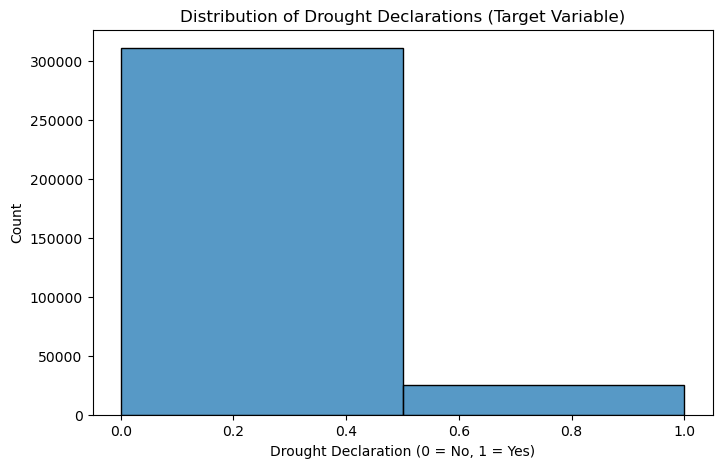

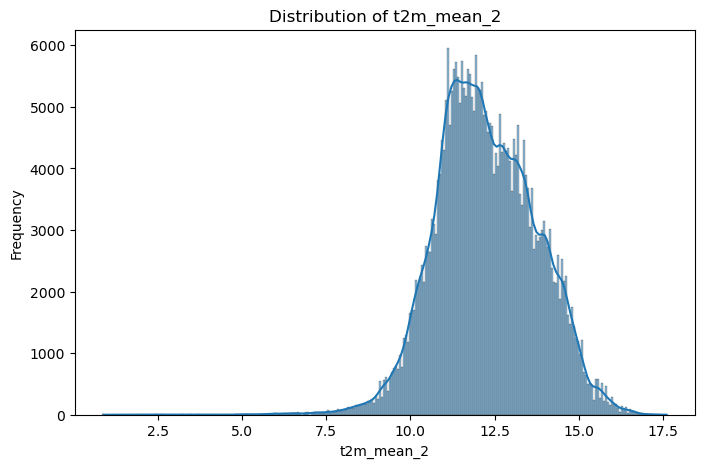

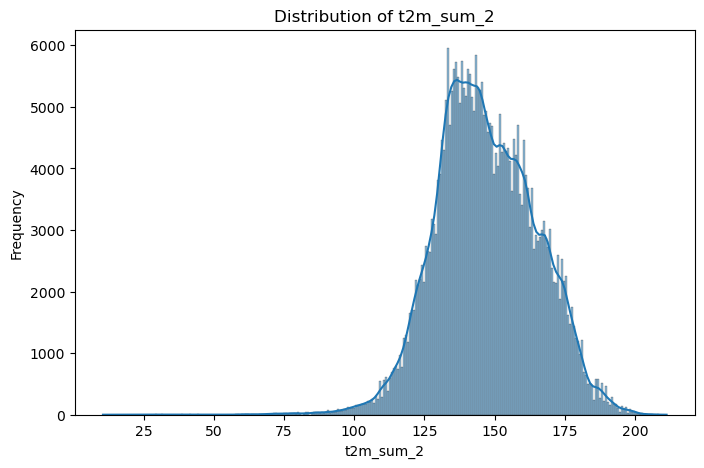

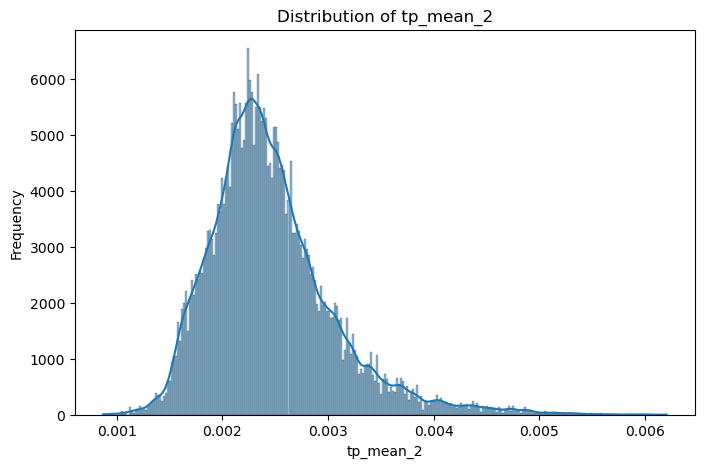

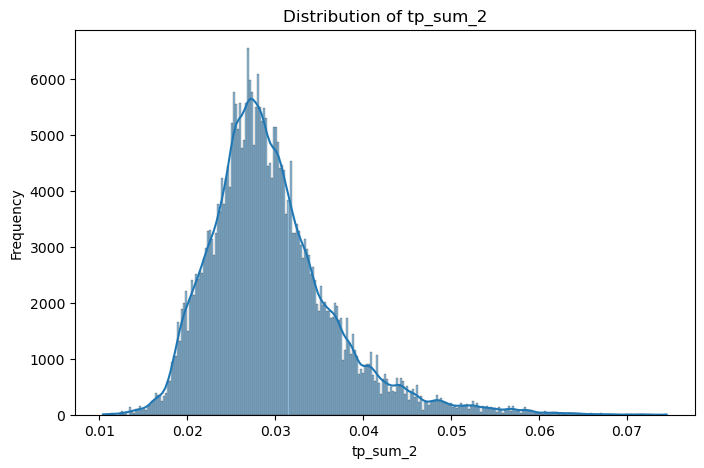

          latitude_1    longitude_1         year_1  year_count_1  \
count  335917.000000  335917.000000  335917.000000      335917.0   
mean       46.390695       2.647832    2010.010258           1.0   
std         2.056190       2.359301       6.024911           0.0   
min        42.473962      -4.587631    2000.000000           1.0   
25%        44.537084       0.669752    2005.000000           1.0   
50%        46.540725       2.385745    2010.000000           1.0   
75%        48.054810       4.729963    2015.000000           1.0   
max        51.063772       8.000078    2020.000000           1.0   

       year_duration_1  applied_1     decision_1  Code Région_1  \
count    335917.000000   335917.0  335917.000000  335917.000000   
mean          1.000777        1.0       0.074176      53.163531   
std           0.030806        0.0       0.262058      25.031865   
min           1.000000        1.0       0.000000      11.000000   
25%           1.000000        1.0       0.000000    

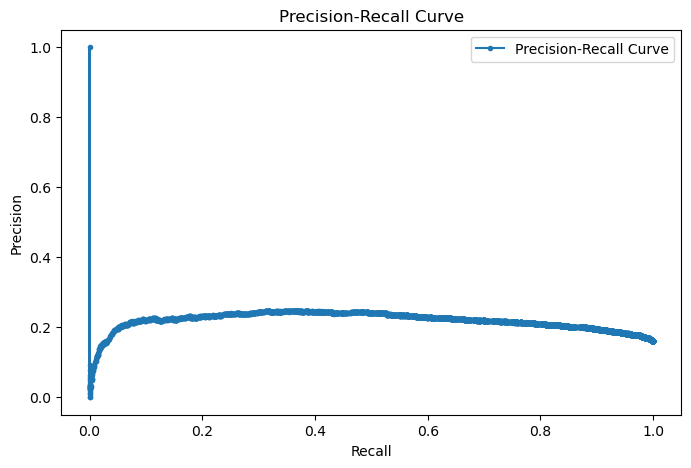

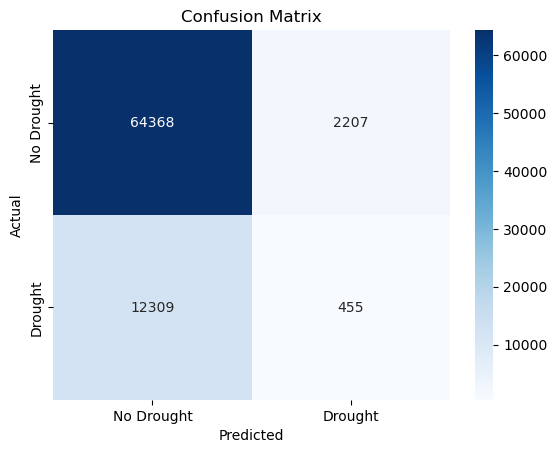

Summary Performance for the XGBoost Model (Threshold = 0.3):
Recall: 0.0356
F1 Score: 0.0590
ROC AUC Score: 0.6459
Classification Report:
              precision    recall  f1-score   support

  No Drought       0.84      0.97      0.90     66575
     Drought       0.17      0.04      0.06     12764

    accuracy                           0.82     79339
   macro avg       0.51      0.50      0.48     79339
weighted avg       0.73      0.82      0.76     79339



In [69]:
# Predicting Drought Emergency Declarations for French Communes

# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import recall_score, precision_recall_curve, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.linear_model import LinearRegression
import datetime
import warnings
warnings.filterwarnings("ignore")

# Load the Dataset (assuming CSV file)
# df = pd.read_csv('french_communes_weather.csv')

# 1. Data Preprocessing
## Check for Missing Values and Remove if Found
print("Checking for missing values...\n")
missing_values = df.isna().sum()
print(missing_values[missing_values > 0])
df.dropna(inplace=True)

# 2. Exploratory Data Analysis (EDA)
## Understand the Target Variable Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['decision_1'], kde=False, bins=2)
plt.title('Distribution of Drought Declarations (Target Variable)')
plt.xlabel('Drought Declaration (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

## Exploratory Visualizations
# Plot the yearly temperature and precipitation trends to understand data behavior
temp_cols = ['t2m_mean_2', 't2m_sum_2']
precip_cols = ['tp_mean_2', 'tp_sum_2']

for col in temp_cols + precip_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Descriptive Statistics
print(df.describe())

# 3. Data Splitting and Temporal Awareness
## Split Data for Temporal Prediction
df = df.sort_values(by='year_1')
train = df[df['year_1'] < df['year_1'].quantile(0.8)]
test = df[df['year_1'] >= df['year_1'].quantile(0.8)]

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

# Split into Features and Target Variables
weather_features = [col for col in df.columns if ('_sum' in col or '_mean' in col) and '_z' not in col]
X_train = train[weather_features]
y_train = train['decision_1']
X_test = test[weather_features]
y_test = test['decision_1']

# 4. Model Building Using XGBoost
from xgboost import XGBClassifier
# Initialize the XGBoost Model
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train the Model
model_xgb.fit(X_train, y_train)

# Make Predictions
y_pred = model_xgb.predict_proba(X_test)[:, 1]
threshold = 0.3  # Adjusted threshold to improve recall for drought cases
y_pred_binary = (y_pred > threshold).astype(int)

# Calculate Metrics
recall = recall_score(y_test, y_pred_binary, pos_label=1)
f1 = f1_score(y_test, y_pred_binary, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred, average='weighted')

# Precision-Recall Curve (Focusing on Recall for Drought)
precision, recall_curve, thresholds = precision_recall_curve(y_test, y_pred)
plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision, marker='.', label='Precision-Recall Curve')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Drought', 'Drought'], yticklabels=['No Drought', 'Drought'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 5. Summary Performance for the XGBoost Model
print("Summary Performance for the XGBoost Model (Threshold = 0.3):")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_binary, target_names=['No Drought', 'Drought'], zero_division=1))

# End of Notebook


### Optuna

Checking for missing values...

Series([], dtype: int64)


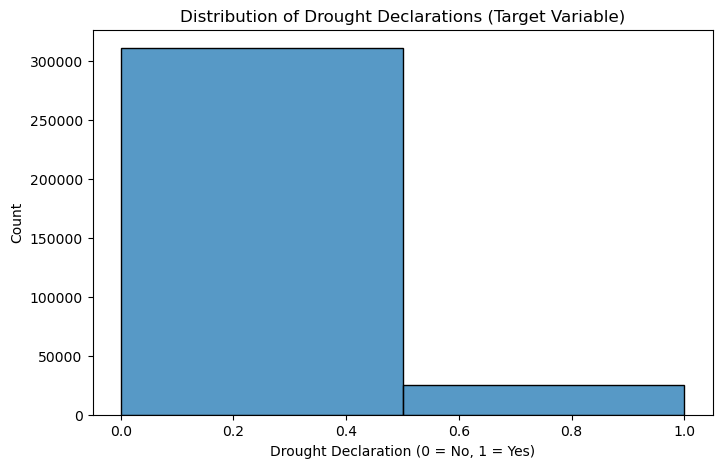

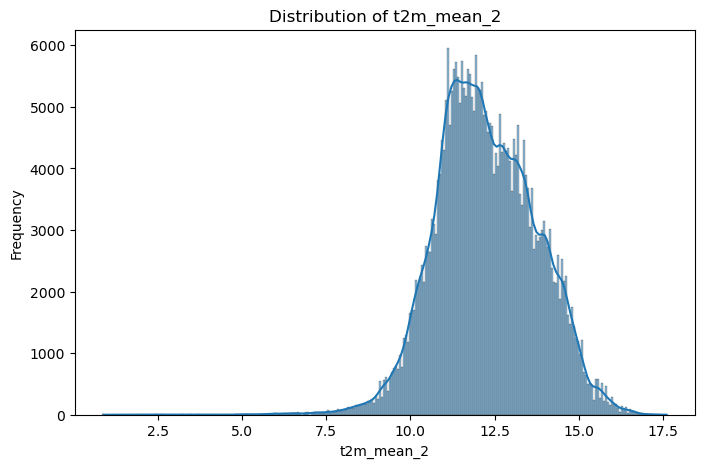

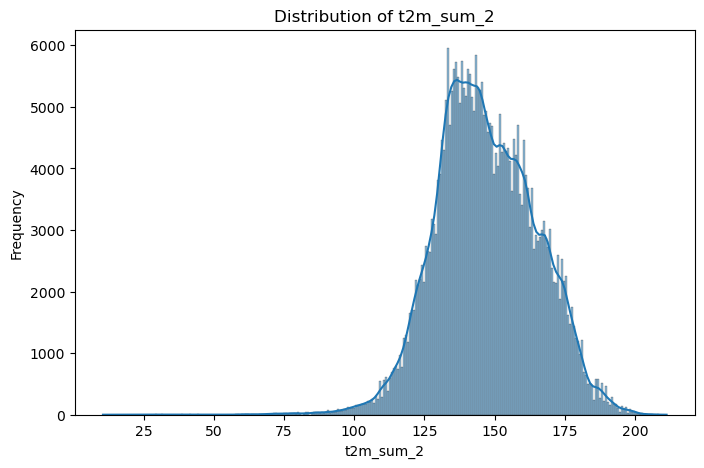

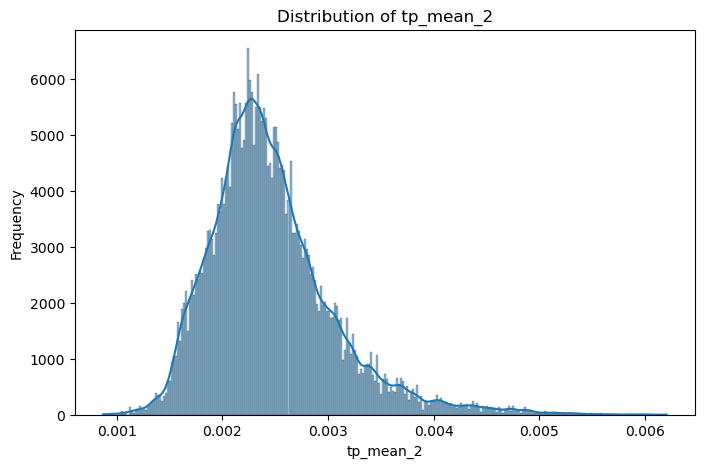

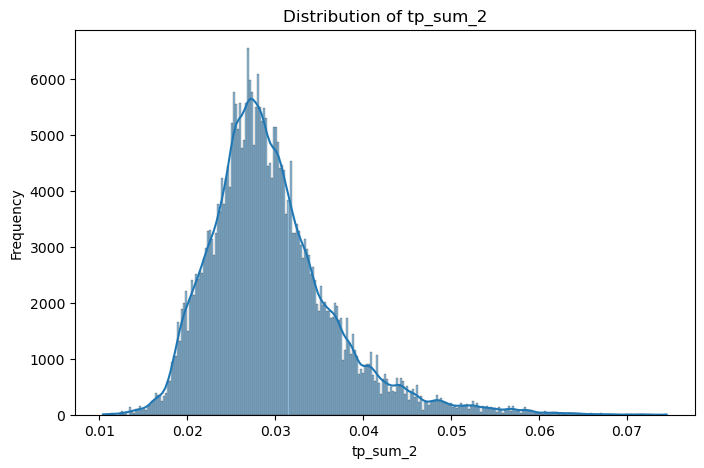

[I 2024-11-01 19:21:53,177] A new study created in memory with name: no-name-482e03d5-c14a-426f-830f-98c7e64a7a4c


          latitude_1    longitude_1         year_1  year_count_1  \
count  335917.000000  335917.000000  335917.000000      335917.0   
mean       46.390695       2.647832    2010.010258           1.0   
std         2.056190       2.359301       6.024911           0.0   
min        42.473962      -4.587631    2000.000000           1.0   
25%        44.537084       0.669752    2005.000000           1.0   
50%        46.540725       2.385745    2010.000000           1.0   
75%        48.054810       4.729963    2015.000000           1.0   
max        51.063772       8.000078    2020.000000           1.0   

       year_duration_1  applied_1     decision_1  Code Région_1  \
count    335917.000000   335917.0  335917.000000  335917.000000   
mean          1.000777        1.0       0.074176      53.163531   
std           0.030806        0.0       0.262058      25.031865   
min           1.000000        1.0       0.000000      11.000000   
25%           1.000000        1.0       0.000000    

[I 2024-11-01 19:21:53,490] Trial 0 finished with value: 0.00940144155437167 and parameters: {'n_estimators': 69, 'max_depth': 5, 'learning_rate': 0.034106917392122175, 'subsample': 0.5037445584497519, 'colsample_bytree': 0.8731985414438632}. Best is trial 0 with value: 0.00940144155437167.
[I 2024-11-01 19:21:54,214] Trial 1 finished with value: 0.00399561266060796 and parameters: {'n_estimators': 62, 'max_depth': 10, 'learning_rate': 0.01957255955981667, 'subsample': 0.5653555849527317, 'colsample_bytree': 0.7608388231879176}. Best is trial 0 with value: 0.00940144155437167.
[I 2024-11-01 19:21:54,617] Trial 2 finished with value: 0.0 and parameters: {'n_estimators': 138, 'max_depth': 3, 'learning_rate': 0.010622469998365535, 'subsample': 0.5119241981441149, 'colsample_bytree': 0.7133563660874762}. Best is trial 0 with value: 0.00940144155437167.
[I 2024-11-01 19:21:56,355] Trial 3 finished with value: 0.013945471638984644 and parameters: {'n_estimators': 273, 'max_depth': 8, 'learni

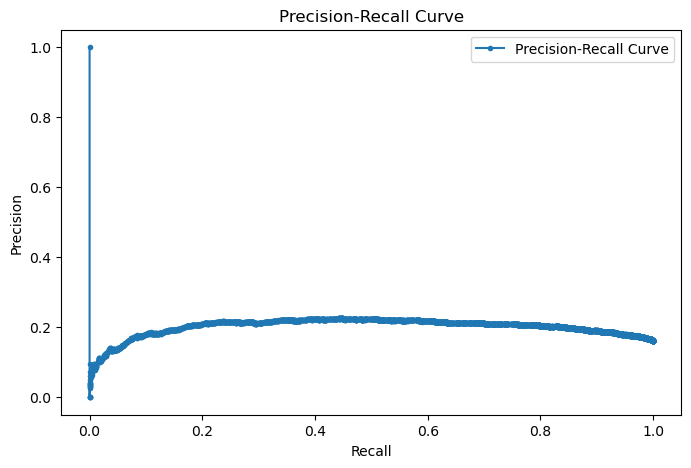

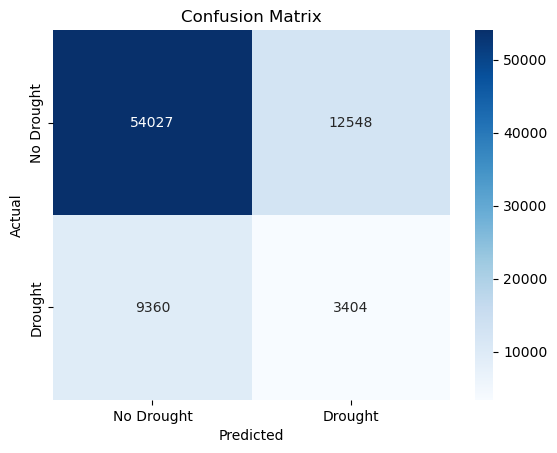

Summary Performance for the Optimized XGBoost Model (Threshold = 0.3):
Recall: 0.2667
F1 Score: 0.2371
ROC AUC Score: 0.6226
Classification Report:
              precision    recall  f1-score   support

  No Drought       0.85      0.81      0.83     66575
     Drought       0.21      0.27      0.24     12764

    accuracy                           0.72     79339
   macro avg       0.53      0.54      0.53     79339
weighted avg       0.75      0.72      0.74     79339

Best Hyperparameters found by Optuna:
{'n_estimators': 175, 'max_depth': 3, 'learning_rate': 0.25627680556608484, 'subsample': 0.8722367554292767, 'colsample_bytree': 0.9857015892849269}


In [30]:
# Predicting Drought Emergency Declarations for French Communes

# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import recall_score, precision_recall_curve, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.linear_model import LinearRegression
import datetime
import warnings
warnings.filterwarnings("ignore")

# Load the Dataset (assuming CSV file)
# df = pd.read_csv('french_communes_weather.csv')

# 1. Data Preprocessing
## Check for Missing Values and Remove if Found
print("Checking for missing values...\n")
missing_values = df.isna().sum()
print(missing_values[missing_values > 0])
df.dropna(inplace=True)

# 2. Exploratory Data Analysis (EDA)
## Understand the Target Variable Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['decision_1'], kde=False, bins=2)
plt.title('Distribution of Drought Declarations (Target Variable)')
plt.xlabel('Drought Declaration (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

## Exploratory Visualizations
# Plot the yearly temperature and precipitation trends to understand data behavior
temp_cols = ['t2m_mean_2', 't2m_sum_2']
precip_cols = ['tp_mean_2', 'tp_sum_2']

for col in temp_cols + precip_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Descriptive Statistics
print(df.describe())

# 3. Data Splitting and Temporal Awareness
## Split Data for Temporal Prediction
df = df.sort_values(by='year_1')
train = df[df['year_1'] < df['year_1'].quantile(0.8)]
test = df[df['year_1'] >= df['year_1'].quantile(0.8)]

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

# Split into Features and Target Variables
weather_features = [col for col in df.columns if ('_sum' in col or '_mean' in col) and '_z' not in col]
X_train = train[weather_features]
y_train = train['decision_1']
X_test = test[weather_features]
y_test = test['decision_1']

# 4. Model Building Using XGBoost and Optuna for Hyperparameter Tuning
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score

def objective(trial):
    # Define the hyperparameters to tune
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }
    
    # Initialize the model with the suggested hyperparameters
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict_proba(X_test)[:, 1]
    y_pred_binary = (y_pred > threshold).astype(int)
    
    # Calculate recall, as we want to focus on minimizing missed drought cases
    recall = recall_score(y_test, y_pred_binary, pos_label=1)
    return recall

# Use Optuna to find the best hyperparameters
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Train the Best Model
best_params = study.best_params
model_xgb = XGBClassifier(**best_params, random_state=42, use_label_encoder=False, eval_metric='logloss')
model_xgb.fit(X_train, y_train)

# Make Predictions
y_pred = model_xgb.predict_proba(X_test)[:, 1]
threshold = 0.1  # Adjusted threshold to improve recall for drought cases
y_pred_binary = (y_pred > threshold).astype(int)

# Calculate Metrics
recall = recall_score(y_test, y_pred_binary, pos_label=1)
f1 = f1_score(y_test, y_pred_binary, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred, average='weighted')

# Precision-Recall Curve (Focusing on Recall for Drought)
precision, recall_curve, thresholds = precision_recall_curve(y_test, y_pred)
plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision, marker='.', label='Precision-Recall Curve')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Drought', 'Drought'], yticklabels=['No Drought', 'Drought'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 5. Summary Performance for the XGBoost Model (Optimized with Optuna)
print("Summary Performance for the Optimized XGBoost Model (Threshold = 0.3):")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_binary, target_names=['No Drought', 'Drought'], zero_division=1))

# Print the best hyperparameters found by Optuna
print("Best Hyperparameters found by Optuna:")
print(best_params)

# End of Notebook


#### Precision and Classification Report:

- **No Drought** (Class 0):
  - **Precision** is 0.89, which means when the model predicts No Drought, it is correct in 89% of the cases.
  - **Recall** dropped to 0.49, indicating that only about 49% of the true No Drought cases are being correctly predicted, which is likely due to the lower threshold allowing more predictions of Drought.
- **Drought** (Class 1):
  - **Precision** is 0.21, meaning the model often incorrectly predicts Drought when there is no actual drought.
  - **Recall** has greatly improved to 0.69. This means the model has a much better rate of capturing actual drought cases, even at the cost of misclassifying some No Drought instances as Drought.
  - **Accuracy** dropped to 0.53, which suggests that overall correct predictions decreased, but this is acceptable in this context since the goal is to capture as many true droughts as possible, even at the cost of more false positives.

In [27]:
df.columns

Index(['insee_1', 'nom_commune_1', 'latitude_1', 'longitude_1', 'year_1',
       'year_count_1', 'year_duration_1', 'applied_1', 'decision_1',
       'Code Postal_1', 'Département_1', 'Région_1', 'Code Département_1',
       'Code Région_1', 'latitude_rad_1', 'longitude_rad_1', 'latitude_2',
       'longitude_2', 'year_2', 't2m_z_sum_2', 't2m_z_mean_2', 'tp_z_sum_2',
       'tp_z_mean_2', 'e_z_sum_2', 'e_z_mean_2', 'pev_z_sum_2', 'pev_z_mean_2',
       'stl1_z_sum_2', 'stl1_z_mean_2', 'stl2_z_sum_2', 'stl2_z_mean_2',
       'slt_z_sum_2', 'slt_z_mean_2', 'swvl1_z_sum_2', 'swvl1_z_mean_2',
       'swvl2_z_sum_2', 'swvl2_z_mean_2', 't2m_sum_2', 't2m_mean_2',
       'tp_sum_2', 'tp_mean_2', 'e_sum_2', 'e_mean_2', 'pev_sum_2',
       'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2', 'stl2_sum_2', 'stl2_mean_2',
       'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2', 'swvl1_mean_2', 'swvl2_sum_2',
       'swvl2_mean_2', 'latitude_rad_2', 'longitude_rad_2', 'distance_km'],
      dtype='object')

#### LightGBM

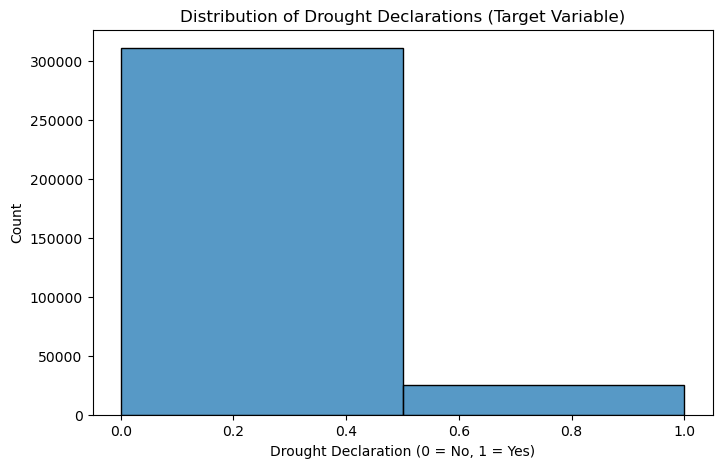

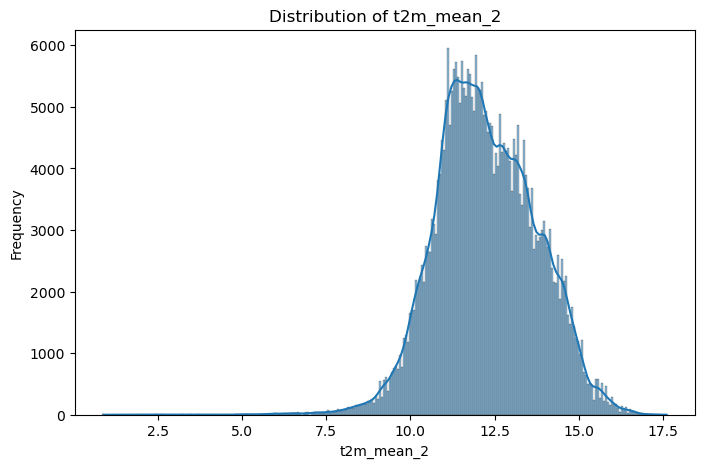

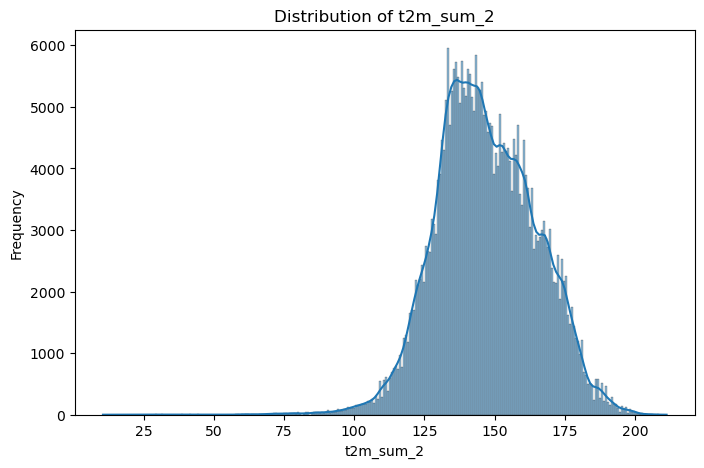

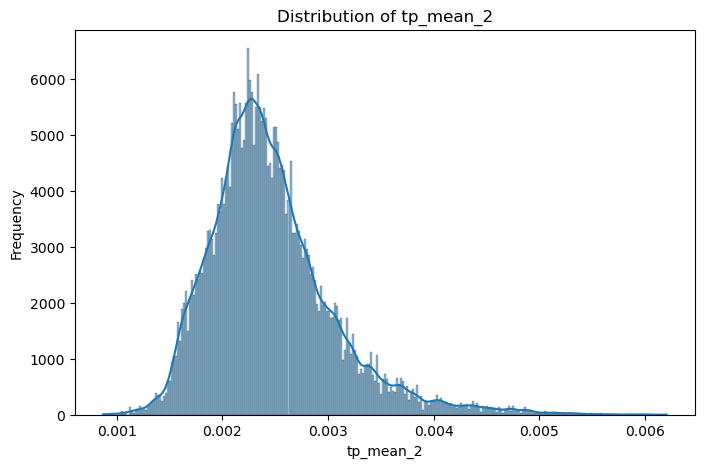

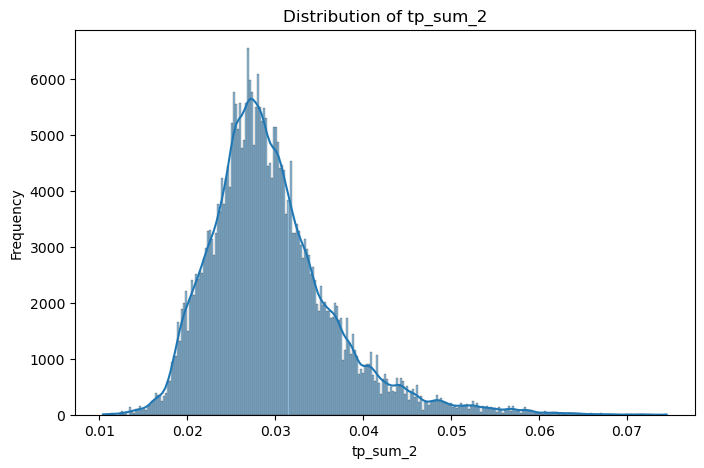

          latitude_1    longitude_1         year_1  year_count_1  \
count  335917.000000  335917.000000  335917.000000      335917.0   
mean       46.390695       2.647832    2010.010258           1.0   
std         2.056190       2.359301       6.024911           0.0   
min        42.473962      -4.587631    2000.000000           1.0   
25%        44.537084       0.669752    2005.000000           1.0   
50%        46.540725       2.385745    2010.000000           1.0   
75%        48.054810       4.729963    2015.000000           1.0   
max        51.063772       8.000078    2020.000000           1.0   

       year_duration_1  applied_1     decision_1  Code Région_1  \
count    335917.000000   335917.0  335917.000000  335917.000000   
mean          1.000777        1.0       0.074176      53.163531   
std           0.030806        0.0       0.262058      25.031865   
min           1.000000        1.0       0.000000      11.000000   
25%           1.000000        1.0       0.000000    

[I 2024-11-01 20:07:24,249] A new study created in memory with name: no-name-7a6b0c34-6af2-4030-aaed-b7c7d1a83d53


Training set shape: (256578, 150)
Testing set shape: (79339, 150)
[LightGBM] [Info] Number of positive: 12153, number of negative: 244425
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001623 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4090
[LightGBM] [Info] Number of data points in the train set: 256578, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[I 2024-11-01 20:07:26,333] Trial 0 finished with value: 0.3211621923646664 and parameters: {'n_estimators': 280, 'max_depth': 8, 'learning_rate': 0.0060540930160762185, 'subsample': 0.9938951836881078, 'colsample_bytree': 0.7108789157188624}. Best is trial 0 with value: 0.3211621923646664.


[LightGBM] [Info] Number of positive: 12153, number of negative: 244425
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002007 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4090
[LightGBM] [Info] Number of data points in the train set: 256578, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


...

[LightGBM] [Info] Number of positive: 12153, number of negative: 244425
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002100 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4090
[LightGBM] [Info] Number of data points in the train set: 256578, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2024-11-01 20:08:18,295] Trial 48 finished with value: 0.3042791465283508 and parameters: {'n_estimators': 280, 'max_depth': 5, 'learning_rate': 0.009375802379024595, 'subsample': 0.9002250025070886, 'colsample_bytree': 0.5668087864534062}. Best is trial 33 with value: 0.3300712690139347.


[LightGBM] [Info] Number of positive: 12153, number of negative: 244425
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4090
[LightGBM] [Info] Number of data points in the train set: 256578, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

[I 2024-11-01 20:08:19,456] Trial 49 finished with value: 0.31968927397669555 and parameters: {'n_estimators': 258, 'max_depth': 4, 'learning_rate': 0.0015960783803950554, 'subsample': 0.8127810977580043, 'colsample_bytree': 0.5933955757084295}. Best is trial 33 with value: 0.3300712690139347.


[LightGBM] [Info] Number of positive: 12153, number of negative: 244425
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4090
[LightGBM] [Info] Number of data points in the train set: 256578, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

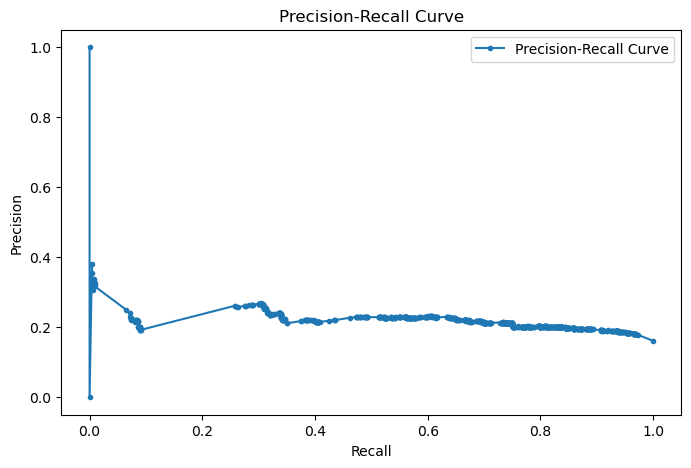

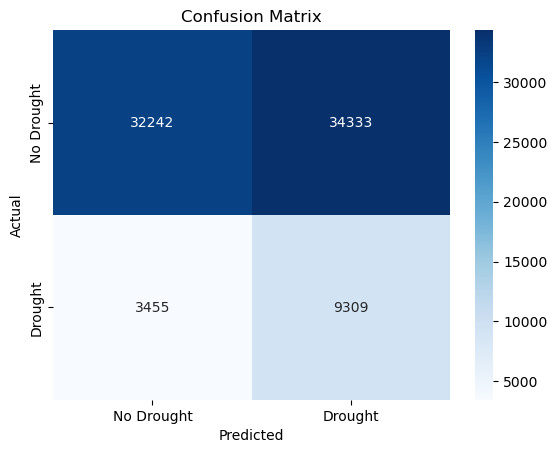

Summary Performance for the Optimized LightGBM Model:
Recall: 0.7293
F1 Score: 0.3301
ROC AUC Score: 0.6381
Classification Report:
              precision    recall  f1-score   support

  No Drought       0.90      0.48      0.63     66575
     Drought       0.21      0.73      0.33     12764

    accuracy                           0.52     79339
   macro avg       0.56      0.61      0.48     79339
weighted avg       0.79      0.52      0.58     79339

Best Hyperparameters found by Optuna:
{'n_estimators': 266, 'max_depth': 3, 'learning_rate': 0.0030015301275744884, 'subsample': 0.7882601807143693, 'colsample_bytree': 0.595196655008692}


In [71]:
# Predicting Drought Emergency Declarations for French Communes

# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import recall_score, precision_recall_curve, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from lightgbm import LGBMClassifier
import optuna
import datetime
import warnings
warnings.filterwarnings("ignore")

# Load the Dataset (assuming CSV file)
# df = pd.read_csv('french_communes_weather.csv')

# 1. Data Preprocessing
## Create a copy of the dataset to work on
df_copy = df.copy()

# Rename 'Code Département_1' to 'Code_Departement_1' to avoid whitespace issues
if 'Code Département_1' in df_copy.columns:
    df_copy.rename(columns={'Code Département_1': 'Code_Departement_1'}, inplace=True)

## Define preprocessing for the categorical feature 'Code_Departement_1'
if 'Code_Departement_1' in df_copy.columns:
    onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')
    encoded_departments = onehot_encoder.fit_transform(df_copy[['Code_Departement_1']])
    department_encoded_df = pd.DataFrame(encoded_departments, columns=onehot_encoder.get_feature_names_out(['Code_Departement_1']))

    # Reset indexes to ensure proper concatenation
    df_copy = df_copy.reset_index(drop=True)
    department_encoded_df = department_encoded_df.reset_index(drop=True)

    # Add the encoded department columns to the original dataframe copy and drop the original column
    df_copy = pd.concat([df_copy.drop(columns=['Code_Departement_1']), department_encoded_df], axis=1)
else:
    print("The column 'Code_Departement_1' was not found in the dataset. Please verify the column name.")

# 2. Exploratory Data Analysis (EDA)
## Understand the Target Variable Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_copy['decision_1'], kde=False, bins=2)
plt.title('Distribution of Drought Declarations (Target Variable)')
plt.xlabel('Drought Declaration (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

## Exploratory Visualizations
# Plot the yearly temperature and precipitation trends to understand data behavior
temp_cols = ['t2m_mean_2', 't2m_sum_2']
precip_cols = ['tp_mean_2', 'tp_sum_2']

for col in temp_cols + precip_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_copy[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Descriptive Statistics
print(df_copy.describe())

# 3. Data Splitting and Temporal Awareness
## Split Data for Temporal Prediction
df_copy = df_copy.sort_values(by='year_1')
train = df_copy[df_copy['year_1'] < df_copy['year_1'].quantile(0.8)]
test = df_copy[df_copy['year_1'] >= df_copy['year_1'].quantile(0.8)]

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

# Split into Features and Target Variables
weather_features = [col for col in df_copy.columns if ('_sum' in col or '_mean' in col) and '_z' not in col]
all_features = list(department_encoded_df.columns) + weather_features if 'Code_Departement_1' in df.columns else weather_features

X_train = train[all_features]
y_train = train['decision_1']
X_test = test[all_features]
y_test = test['decision_1']

# 4. Model Building Using LightGBM and Optuna for Hyperparameter Tuning
# Define the model
model = LGBMClassifier(random_state=42, class_weight='balanced')

# Use Optuna for hyperparameter tuning to find the best parameters for LightGBM
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0)
    }
    model.set_params(**param)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    y_pred_binary = (y_pred > 0.5).astype(int)
    f1 = f1_score(y_test, y_pred_binary, pos_label=1)
    return f1

# Use Optuna to find the best hyperparameters
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Train the Best Model
best_params = study.best_params
model.set_params(**best_params)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict_proba(X_test)[:, 1]
y_pred_binary = (y_pred > 0.5).astype(int)

# Calculate Metrics
recall = recall_score(y_test, y_pred_binary, pos_label=1)
f1 = f1_score(y_test, y_pred_binary, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred, average='weighted')

# Precision-Recall Curve (Focusing on Recall for Drought)
precision, recall_curve, thresholds = precision_recall_curve(y_test, y_pred)
plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision, marker='.', label='Precision-Recall Curve')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Drought', 'Drought'], yticklabels=['No Drought', 'Drought'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 5. Summary Performance for the LightGBM Model
print(f"Summary Performance for the Optimized LightGBM Model:")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_binary, target_names=['No Drought', 'Drought'], zero_division=1))

# Print the best hyperparameters found by Optuna
print("Best Hyperparameters found by Optuna:")
print(best_params)

# End of Notebook


In [34]:
#!pip install lightgbm

### Threshold tunning for best model

Training set shape: (256578, 150)
Testing set shape: (79339, 150)
[LightGBM] [Info] Number of positive: 12153, number of negative: 244425
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000866 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4090
[LightGBM] [Info] Number of data points in the train set: 256578, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

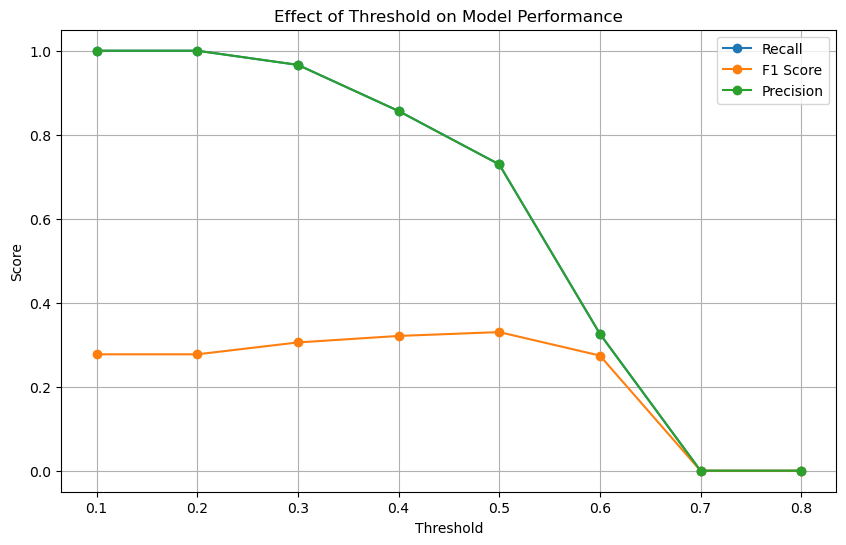

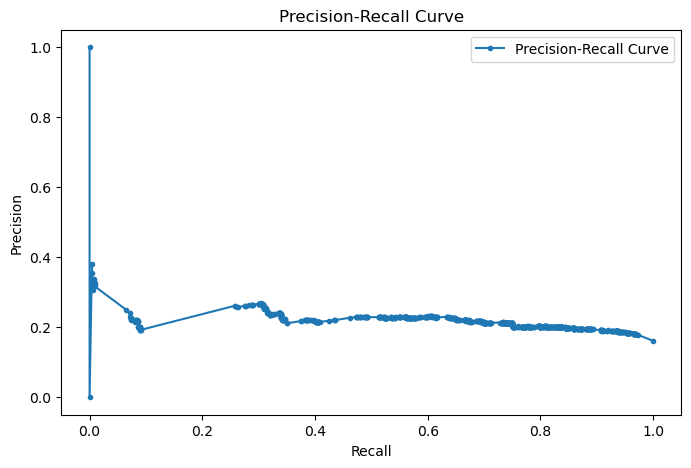

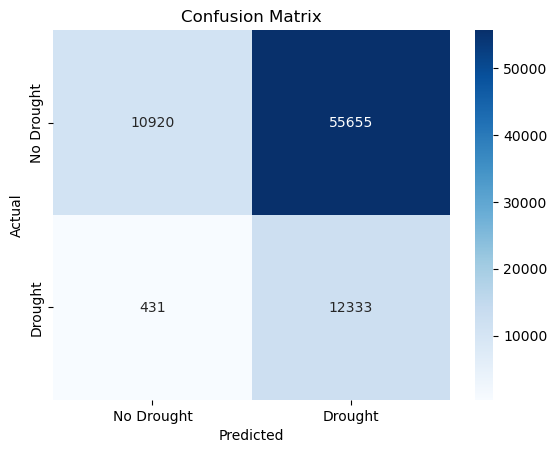

Summary Performance for the Optimized LightGBM Model with Threshold = 0.3:
Recall: 0.9662
F1 Score: 0.3055
ROC AUC Score: 0.6381
Classification Report:
              precision    recall  f1-score   support

  No Drought       0.96      0.16      0.28     66575
     Drought       0.18      0.97      0.31     12764

    accuracy                           0.29     79339
   macro avg       0.57      0.57      0.29     79339
weighted avg       0.84      0.29      0.28     79339

Best Hyperparameters used for LightGBM Model:
{'n_estimators': 266, 'max_depth': 3, 'learning_rate': 0.0030015301275744884, 'subsample': 0.7882601807143693, 'colsample_bytree': 0.595196655008692}


In [72]:
# Predicting Drought Emergency Declarations for French Communes with LightGBM and Threshold Tuning

# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import recall_score, precision_recall_curve, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from lightgbm import LGBMClassifier
import optuna
import datetime
import warnings
warnings.filterwarnings("ignore")

# Load the Dataset (assuming CSV file)
# df = pd.read_csv('french_communes_weather.csv')

# 1. Data Preprocessing
## Create a copy of the dataset to work on
df_copy = df.copy()

# Rename 'Code Département_1' to 'Code_Departement_1' to avoid whitespace issues
if 'Code Département_1' in df_copy.columns:
    df_copy.rename(columns={'Code Département_1': 'Code_Departement_1'}, inplace=True)

## Define preprocessing for the categorical feature 'Code_Departement_1'
if 'Code_Departement_1' in df_copy.columns:
    onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')
    encoded_departments = onehot_encoder.fit_transform(df_copy[['Code_Departement_1']])
    department_encoded_df = pd.DataFrame(encoded_departments, columns=onehot_encoder.get_feature_names_out(['Code_Departement_1']))

    # Reset indexes to ensure proper concatenation
    df_copy = df_copy.reset_index(drop=True)
    department_encoded_df = department_encoded_df.reset_index(drop=True)

    # Add the encoded department columns to the original dataframe copy and drop the original column
    df_copy = pd.concat([df_copy.drop(columns=['Code_Departement_1']), department_encoded_df], axis=1)
else:
    print("The column 'Code_Departement_1' was not found in the dataset. Please verify the column name.")

# 2. Data Splitting and Temporal Awareness
## Split Data for Temporal Prediction
df_copy = df_copy.sort_values(by='year_1')
train = df_copy[df_copy['year_1'] < df_copy['year_1'].quantile(0.8)]
test = df_copy[df_copy['year_1'] >= df_copy['year_1'].quantile(0.8)]

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

# Split into Features and Target Variables
weather_features = [col for col in df_copy.columns if ('_sum' in col or '_mean' in col) and '_z' not in col]
all_features = list(department_encoded_df.columns) + weather_features if 'Code_Departement_1' in df.columns else weather_features

X_train = train[all_features]
y_train = train['decision_1']
X_test = test[all_features]
y_test = test['decision_1']

# 3. Model Building Using LightGBM
# Define the model
model = LGBMClassifier(
    n_estimators=266, 
    max_depth=3, 
    learning_rate=0.0030015301275744884, 
    subsample=0.7882601807143693, 
    colsample_bytree=0.595196655008692, 
    random_state=42,
    class_weight='balanced'
)

# Train the Best Model
model.fit(X_train, y_train)

# Make Predictions
y_pred_probs = model.predict_proba(X_test)[:, 1]

# 4. Experimenting with Different Thresholds
thresholds = np.arange(0.1, 0.9, 0.1)  # Try different thresholds from 0.1 to 0.9
results = []

for threshold in thresholds:
    y_pred_binary = (y_pred_probs > threshold).astype(int)
    recall = recall_score(y_test, y_pred_binary, pos_label=1)
    f1 = f1_score(y_test, y_pred_binary, pos_label=1)
    precision = recall_score(y_test, y_pred_binary, pos_label=1)
    results.append((threshold, recall, f1, precision))

# Plot Precision, Recall, and F1 Score for Different Thresholds
results_df = pd.DataFrame(results, columns=['Threshold', 'Recall', 'F1 Score', 'Precision'])
plt.figure(figsize=(10, 6))
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall', marker='o')
plt.plot(results_df['Threshold'], results_df['F1 Score'], label='F1 Score', marker='o')
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision', marker='o')
plt.title('Effect of Threshold on Model Performance')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.show()

# Select a Threshold and Make Final Predictions
best_threshold = 0.3  # This is the initial threshold, but you may change it based on the above analysis
y_pred_binary = (y_pred_probs > best_threshold).astype(int)

# 5. Calculate Metrics for the Selected Threshold
recall = recall_score(y_test, y_pred_binary, pos_label=1)
f1 = f1_score(y_test, y_pred_binary, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred_probs, average='weighted')

# Precision-Recall Curve (Focusing on Recall for Drought)
precision, recall_curve, thresholds = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision, marker='.', label='Precision-Recall Curve')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Drought', 'Drought'], yticklabels=['No Drought', 'Drought'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 6. Summary Performance for the LightGBM Model
print(f"Summary Performance for the Optimized LightGBM Model with Threshold = {best_threshold:.1f}:")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_binary, target_names=['No Drought', 'Drought'], zero_division=1))

# Best Hyperparameters found by Optuna
print("Best Hyperparameters used for LightGBM Model:")
print(best_params)

# End of Notebook


Training set shape: (256578, 150)
Testing set shape: (79339, 150)
[LightGBM] [Info] Number of positive: 12153, number of negative: 244425
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4090
[LightGBM] [Info] Number of data points in the train set: 256578, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

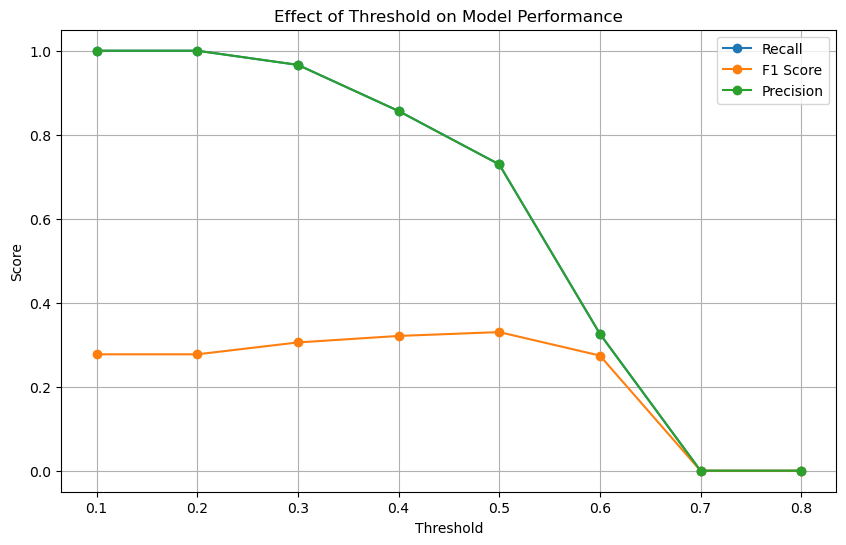

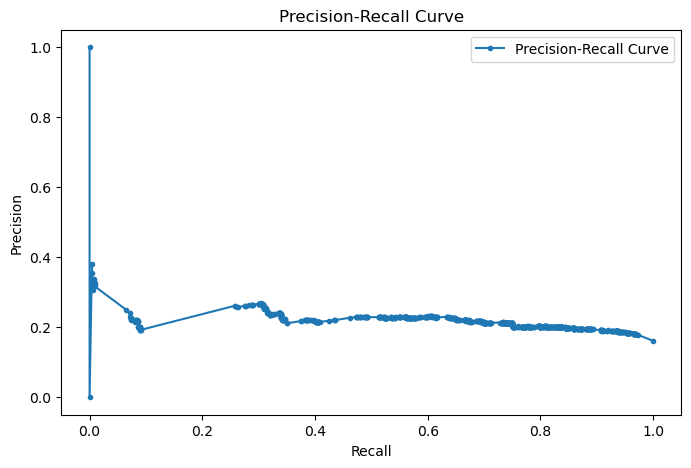

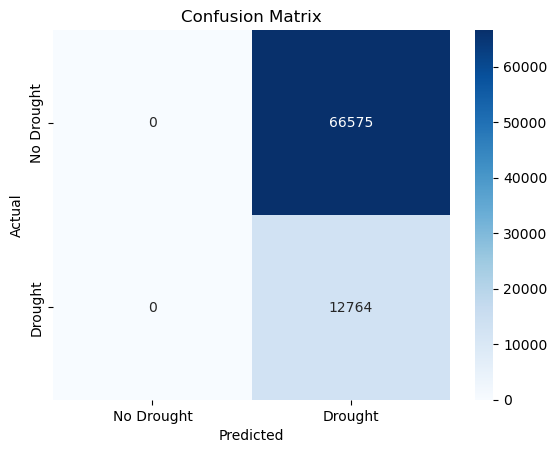

Summary Performance for the Optimized LightGBM Model with Threshold = 0.2:
Recall: 1.0000
F1 Score: 0.2772
ROC AUC Score: 0.6381
Classification Report:
              precision    recall  f1-score   support

  No Drought       1.00      0.00      0.00     66575
     Drought       0.16      1.00      0.28     12764

    accuracy                           0.16     79339
   macro avg       0.58      0.50      0.14     79339
weighted avg       0.87      0.16      0.04     79339

Best Hyperparameters used for LightGBM Model:
{'n_estimators': 266, 'max_depth': 3, 'learning_rate': 0.0030015301275744884, 'subsample': 0.7882601807143693, 'colsample_bytree': 0.595196655008692}


In [76]:
# Predicting Drought Emergency Declarations for French Communes with LightGBM and Threshold Tuning

# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import recall_score, precision_recall_curve, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from lightgbm import LGBMClassifier
import optuna
import datetime
import warnings
warnings.filterwarnings("ignore")

# Load the Dataset (assuming CSV file)
# df = pd.read_csv('french_communes_weather.csv')

# 1. Data Preprocessing
## Create a copy of the dataset to work on
df_copy = df.copy()

# Rename 'Code Département_1' to 'Code_Departement_1' to avoid whitespace issues
if 'Code Département_1' in df_copy.columns:
    df_copy.rename(columns={'Code Département_1': 'Code_Departement_1'}, inplace=True)

## Define preprocessing for the categorical feature 'Code_Departement_1'
if 'Code_Departement_1' in df_copy.columns:
    onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')
    encoded_departments = onehot_encoder.fit_transform(df_copy[['Code_Departement_1']])
    department_encoded_df = pd.DataFrame(encoded_departments, columns=onehot_encoder.get_feature_names_out(['Code_Departement_1']))

    # Reset indexes to ensure proper concatenation
    df_copy = df_copy.reset_index(drop=True)
    department_encoded_df = department_encoded_df.reset_index(drop=True)

    # Add the encoded department columns to the original dataframe copy and drop the original column
    df_copy = pd.concat([df_copy.drop(columns=['Code_Departement_1']), department_encoded_df], axis=1)
else:
    print("The column 'Code_Departement_1' was not found in the dataset. Please verify the column name.")

# 2. Data Splitting and Temporal Awareness
## Split Data for Temporal Prediction
df_copy = df_copy.sort_values(by='year_1')
train = df_copy[df_copy['year_1'] < df_copy['year_1'].quantile(0.8)]
test = df_copy[df_copy['year_1'] >= df_copy['year_1'].quantile(0.8)]

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

# Split into Features and Target Variables
weather_features = [col for col in df_copy.columns if ('_sum' in col or '_mean' in col) and '_z' not in col]
all_features = list(department_encoded_df.columns) + weather_features if 'Code_Departement_1' in df.columns else weather_features

X_train = train[all_features]
y_train = train['decision_1']
X_test = test[all_features]
y_test = test['decision_1']

# 3. Model Building Using LightGBM
# Define the model
model = LGBMClassifier(
    n_estimators=266, 
    max_depth=3, 
    learning_rate=0.0030015301275744884, 
    subsample=0.7882601807143693, 
    colsample_bytree=0.595196655008692, 
    random_state=42,
    class_weight='balanced'
)

# Train the Best Model
model.fit(X_train, y_train)

# Make Predictions
y_pred_probs = model.predict_proba(X_test)[:, 1]

# 4. Experimenting with Different Thresholds
thresholds = np.arange(0.1, 0.9, 0.1)  # Try different thresholds from 0.1 to 0.9
results = []

for threshold in thresholds:
    y_pred_binary = (y_pred_probs > threshold).astype(int)
    recall = recall_score(y_test, y_pred_binary, pos_label=1)
    f1 = f1_score(y_test, y_pred_binary, pos_label=1)
    precision = recall_score(y_test, y_pred_binary, pos_label=1)
    results.append((threshold, recall, f1, precision))

# Plot Precision, Recall, and F1 Score for Different Thresholds
results_df = pd.DataFrame(results, columns=['Threshold', 'Recall', 'F1 Score', 'Precision'])
plt.figure(figsize=(10, 6))
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall', marker='o')
plt.plot(results_df['Threshold'], results_df['F1 Score'], label='F1 Score', marker='o')
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision', marker='o')
plt.title('Effect of Threshold on Model Performance')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.show()

# Select a Threshold and Make Final Predictions
best_threshold = 0.2  # This is the initial threshold, but you may change it based on the above analysis
y_pred_binary = (y_pred_probs > best_threshold).astype(int)

# 5. Calculate Metrics for the Selected Threshold
recall = recall_score(y_test, y_pred_binary, pos_label=1)
f1 = f1_score(y_test, y_pred_binary, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred_probs, average='weighted')

# Precision-Recall Curve (Focusing on Recall for Drought)
precision, recall_curve, thresholds = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision, marker='.', label='Precision-Recall Curve')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Drought', 'Drought'], yticklabels=['No Drought', 'Drought'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 6. Summary Performance for the LightGBM Model
print(f"Summary Performance for the Optimized LightGBM Model with Threshold = {best_threshold:.1f}:")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_binary, target_names=['No Drought', 'Drought'], zero_division=1))

# Best Hyperparameters found by Optuna
print("Best Hyperparameters used for LightGBM Model:")
print(best_params)

# End of Notebook
